<a href="https://colab.research.google.com/github/falexanderforero/Deep-Learning---Fundamentos/blob/main/Week11/Semana_11_%E2%80%93_Actividad_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

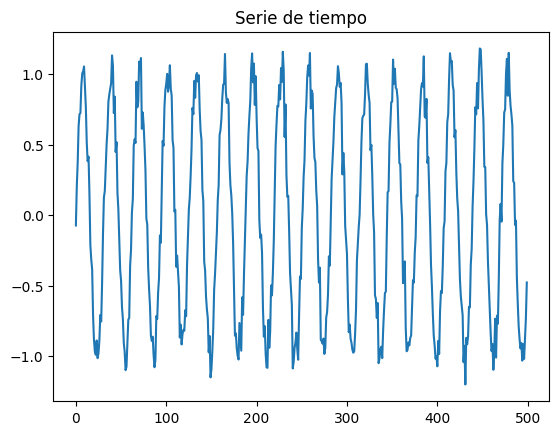

In [2]:
# Generar serie temporal
t = np.linspace(0, 100, 500)
data = np.sin(t) + 0.1*np.random.randn(len(t))

plt.plot(data)
plt.title("Serie de tiempo")
plt.show()

In [3]:
def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])  # ventana
        y.append(data[i+window_size])    # siguiente valor

    return np.array(X), np.array(y)

window_size = 20

X, y = create_sequences(data, window_size)

print(X.shape)  # (samples, timesteps)

(480, 20)


In [4]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Ajustar forma para LSTM: (samples, timesteps, features)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [5]:
model = models.Sequential([
    layers.LSTM(32, input_shape=(window_size, 1)),
    layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',          # error cuadrático medio
    metrics=['mae']      # error absoluto medio
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test),
    batch_size=16
)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.2699 - mae: 0.4619 - val_loss: 0.1419 - val_mae: 0.3324
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0459 - mae: 0.1702 - val_loss: 0.0233 - val_mae: 0.1194
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0135 - mae: 0.0934 - val_loss: 0.0114 - val_mae: 0.0849
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0116 - mae: 0.0880 - val_loss: 0.0128 - val_mae: 0.0881
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0117 - mae: 0.0869 - val_loss: 0.0120 - val_mae: 0.0875


In [7]:
loss, mae = model.evaluate(X_test, y_test)
print(f"MAE: {mae:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0120 - mae: 0.0875 
MAE: 0.0875


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 


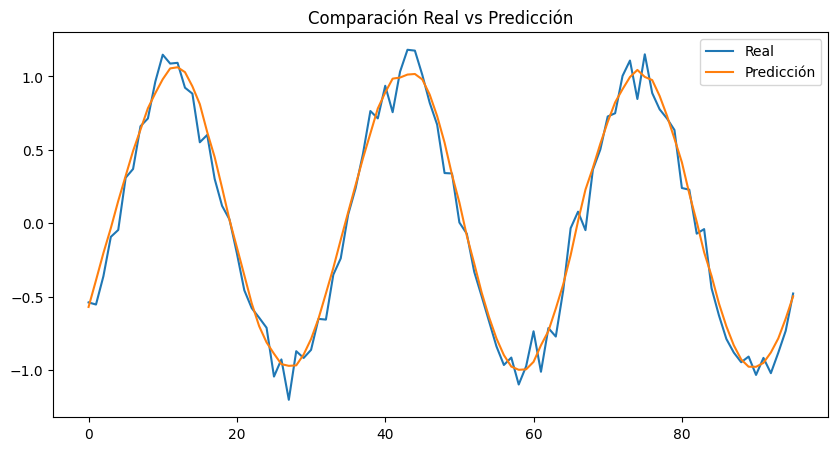

In [8]:
preds = model.predict(X_test)

plt.figure(figsize=(10,5))
plt.plot(y_test, label="Real")
plt.plot(preds, label="Predicción")
plt.legend()
plt.title("Comparación Real vs Predicción")
plt.show()

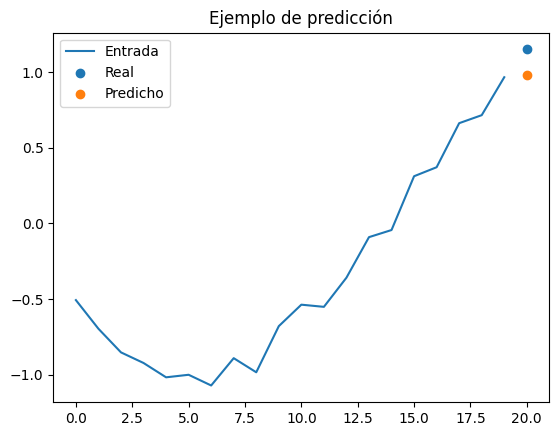

In [9]:
i = 10

plt.plot(range(window_size), X_test[i].squeeze(), label="Entrada")
plt.scatter(window_size, y_test[i], label="Real")
plt.scatter(window_size, preds[i], label="Predicho")
plt.legend()
plt.title("Ejemplo de predicción")
plt.show()

# Readme

## ¿Qué hace una RNN?
Una red recurrente procesa datos secuenciales utilizando información pasada para predecir valores futuros.

## ¿Qué hace la LSTM?
La LSTM mejora las RNN tradicionales al poder recordar información importante por más tiempo y evitar problemas de memoria corta.

## Análisis
El modelo logra seguir la tendencia general de la señal
Puede fallar en picos debido al ruido
Aprende dependencias temporales gracias a las ventanas

## Conclusiones
- Las RNN/LSTM son ideales para datos secuenciales
- Permiten predecir valores futuros basados en historial
- Son usadas en:
  - predicción financiera
  - clima
  - demanda
  - series industriales